In [1]:
import os
import pandas as pd

load_dir = r"C:\Users\olish\Documents\ml_projects\Steps_Predictor\model\data\clean\steps"

dfs = {}

for file_name in os.listdir(load_dir):
    if file_name.endswith(".pkl"):
        file_path = os.path.join(load_dir, file_name)
        
        df_name = file_name.replace(".pkl", "")
        dfs[df_name] = pd.read_pickle(file_path)

In [2]:
import numpy as np

data = dfs['oli']

data["month"] = data.date.dt.month.astype(str).astype("category")
data["time_idx"] = (data["date"] - data["date"].min()).dt.days
data["log_value"] = np.log(data.value + 1e-8)

data.head()

,date,value,month,time_idx,log_value
0,2018-11-18,4390,11,0,8.387085
1,2018-11-19,8335,11,1,9.028219
2,2018-11-20,6946,11,2,8.845921
3,2018-11-21,8350,11,3,9.030017
4,2018-11-22,11054,11,4,9.310548


In [ ]:
print(data.loc[1500:1520])

           date  value month  time_idx  log_value
1500 2021-08-12   5648     8       998   8.639057
1502 2021-08-13  10236     8       999   9.233666
1504 2021-08-14   5843     8      1000   8.673000
1506 2021-08-15   6860     8      1001   8.833463
1508 2021-08-16   7827     8      1002   8.965335
1510 2021-08-17   5198     8      1003   8.556029
1514 2021-08-20   3031     8      1006   8.016648
1516 2021-08-21   9700     8      1007   9.179881
1518 2021-08-22   7560     8      1008   8.930626
1520 2021-08-23  10923     8      1009   9.298626


In [4]:
time_gap_df = data.sort_values(by="time_idx")

time_gap_df["time_diff"] = time_gap_df["time_idx"].diff()

gaps = time_gap_df[time_gap_df["time_diff"] > 1]

print(gaps)

           date  value month  time_idx  log_value  time_diff
1514 2021-08-20   3031     8      1006   8.016648        3.0


In [5]:
complete_date_range = pd.date_range(start=data["date"].min(), end=data["date"].max(), freq='D')

missing_dates = complete_date_range.difference(data["date"])

print(missing_dates)

DatetimeIndex(['2021-08-18', '2021-08-19'], dtype='datetime64[ns]', freq='D')


In [6]:
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting import GroupNormalizer

data["value"] = data["value"].astype(float)
data["log_value"] = data["log_value"].astype(float)

data["group"] = 0

max_prediction_length = 1
max_encoder_length = 30
training_cutoff = data["time_idx"].max() - max_prediction_length

training = TimeSeriesDataSet(
    data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="value",
#     group_ids=["agency", "sku"],
    group_ids=["group"],
    min_encoder_length=max_encoder_length // 2,  
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
#     static_categoricals=["agency", "sku"],
#     static_reals=["avg_population_2017", "avg_yearly_household_income_2017"],
    time_varying_known_categoricals=["month"],
#     variable_groups={"special_days": special_days},  # group of categorical variables can be treated as one variable
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=[
        "value",
        "log_value",
#         "industry_volume",
#         "soda_volume",
#         "avg_max_temp",
#         "avg_volume_by_agency",
#         "avg_volume_by_sku",
    ],
#     target_normalizer=GroupNormalizer(
#         groups=["agency", "sku"], transformation="softplus"
#     ),  # use softplus and normalize by group
     target_normalizer=GroupNormalizer(
         groups=["group"], transformation="softplus"
         ),     
#
     add_relative_time_idx=True,
     add_target_scales=True,
     add_encoder_length=True,
     allow_missing_timesteps=True
)

validation = TimeSeriesDataSet.from_dataset(training, data, predict=True, stop_randomization=True)

batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

In [7]:
from pytorch_forecasting import Baseline
from pytorch_forecasting.metrics import MAE

baseline_predictions = Baseline().predict(val_dataloader, return_y=True)
MAE()(baseline_predictions.output, baseline_predictions.y)

C:\Users\olish\AppData\Local\Temp\ipykernel_24548\1174403642.py:4: UserWarning: In pytorch-forecasting models, on versions 1.1.X, the default optimizer defaults to 'adam', if pytorch_optimizer is not installed, otherwise it defaults to 'ranger' from pytorch_optimizer. From version 1.2.0, the default optimizer will be 'adam' regardless of whether pytorch_optimizer is installed, in order to minimize the number of dependencies in default parameter settings. Users who wish to ensure their code continues using 'ranger' as optimizer should ensure that pytorch_optimizer is installed, and set the optimizer parameter explicitly to 'ranger'.
  baseline_predictions = Baseline().predict(val_dataloader, return_y=True)
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ign

tensor(726.)

In [8]:
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from ranger_adabelief import RangerAdaBelief

pl.seed_everything(42)
trainer = pl.Trainer(
    accelerator="cpu",
    # clipping gradients is a hyperparameter and important to prevent divergance
    # of the gradient for recurrent neural networks
    gradient_clip_val=0.1,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    # not meaningful for finding the learning rate but otherwise very important
    learning_rate=0.03,
    hidden_size=8,  # most important hyperparameter apart from learning rate
    # number of attention heads. Set to up to 4 for large datasets
    attention_head_size=1,
    dropout=0.1,  # between 0.1 and 0.3 are good values
    hidden_continuous_size=8,  # set to <= hidden_size
    loss=QuantileLoss(),
    # reduce learning rate if no improvement in validation loss after x epochs
    # reduce_on_plateau_patience=1000,
)

optimizer = RangerAdaBelief(tft.parameters(), lr=1e-3)

print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")


Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Ranger optimizer loaded. 
Gradient Centralization usage = True
GC applied to both conv and fc layers
Number of parameters in network: 7.5k


c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\pytorch_forecasting\models\temporal_fusion_transformer\__init__.py:171: UserWarning: In pytorch-forecasting models, on versions 1.1.X, the default optimizer defaults to 'adam', if pytorch_optimizer is not installed, otherwise it defaults to 'ranger' from pytorch_optimizer. From version 1.2.0, 

c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\lightning\pytorch\loops\utilities.py:72: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:298: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\lightning\pytorch\trainer\con

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 99 steps due to diverging loss.
Learning rate set to 0.01584893192461113
Restoring states from the checkpoint path at c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\POC\.lr_find_5a7da14e-9ce9-4995-bc95-5d74f6863a0e.ckpt
Restored all states from the checkpoint at c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\POC\.lr_find_5a7da14e-9ce9-4995-bc95-5d74f6863a0e.ckpt
C:\Users\olish\AppData\Local\Temp\ipykernel_24548\1809097343.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


suggested learning rate: 0.01584893192461113


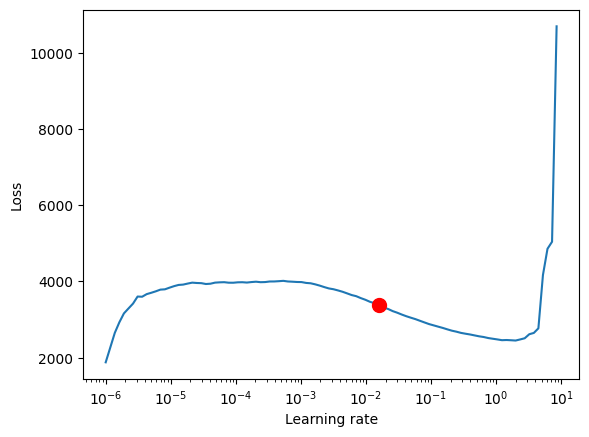

In [9]:
# find optimal learning rate
from lightning.pytorch.tuner import Tuner

res = Tuner(trainer).lr_find(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    max_lr=10.0,
    min_lr=1e-6,
)

print(f"suggested learning rate: {res.suggestion()}")

# Get the plot data
fig = res.plot(show=False, suggest=True)
fig.show()

In [10]:
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

# configure network and trainer
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="cpu",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    limit_train_batches=50,  # coment in for training, running valiation every 30 batches
    # fast_dev_run=True,  # comment in to check that networkor dataset has no serious bugs
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.005,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    # optimizer="Ranger",
    reduce_on_plateau_patience=4,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Number of parameters in network: 19.6k


c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\pytorch_forecasting\models\temporal_fusion_transformer\__init__.py:171: UserWarning: In pytorch-forecasting models, on versions 1.1.X, the default optimizer defaults to 'adam', if pytorch_optimizer is not installed, otherwise it defaults to 'ranger' from pytorch_optimizer. From version 1.2.0, 


   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 72     | train
3  | prescalers                         | ModuleDict                      | 112    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 1.7 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 2.6 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 1.3 K  | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 1.1 K  | train
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 1.1 K  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


ValueError: 'yerr' must not contain negative values

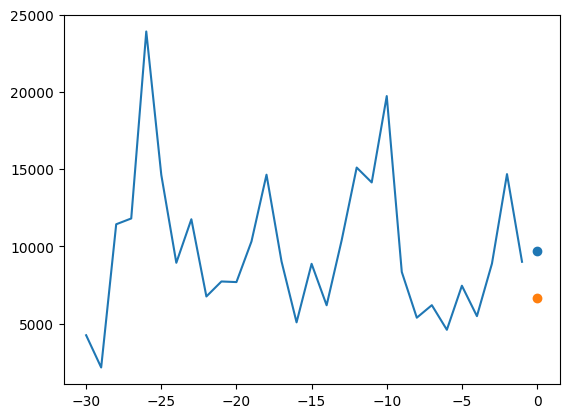

In [11]:
# fit network
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)